[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/quarcs-lab/ds4bolivia/blob/master/notebooks/esda_inequality.ipynb)

# Spatial Inequality

An interactive tutorial measuring regional inequality across Bolivia's 339 municipalities. This notebook covers the Theil index (with between/within decomposition by department), the Gini coefficient, and the Spatial Gini index to assess how much inequality is spatially structured.

## Setup

In [1]:
# Install packages not included in Google Colab's default environment.
# When running locally with UV, these are already installed and this cell is harmless.
!pip install contextily libpysal inequality -q

zsh:1: command not found: pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
import contextily as cx

from libpysal import weights
import inequality
from inequality.gini import Gini_Spatial

import warnings
warnings.filterwarnings('ignore')

## Import data

In [3]:
dataURL = 'https://github.com/quarcs-lab/project2021o-notebook/raw/main/map_and_data.geojson'
gdf = gpd.read_file(dataURL)
gdf.head(3)

,asdf_id,shapeName,COORD_X,COORD_Y,poly_id,mun,mun_id,dep,dep_id,dep_mun,...,co2018,co2019,co2020,tr400_co2015,tr400_co2016,tr400_co2017,tr400_co2018,tr400_co2019,tr400_co2020,geometry
0,0,Esmeralda,-68.086369,-18.945744,178,Esmeralda,40505,Oruro,5,Oruro-Esmeralda,...,406.84192,408.98264,410.99747,400.56021,402.63989,404.73074,406.83206,408.94409,411.06708,"MULTIPOLYGON (((-68.26703 -18.81616, -68.23937..."
1,1,Santuario de Quillacas,-66.813557,-19.318918,169,Quillacas,40202,Oruro,5,Oruro-Quillacas,...,406.64880,408.32587,410.74161,399.42441,401.71268,404.01230,406.32236,408.64389,410.97791,"MULTIPOLYGON (((-66.50208 -19.3599, -66.56355 ..."
2,2,Pampa Aullagas,-67.165981,-19.231799,185,Pampa Aullagas,40802,Oruro,5,Oruro-Pampa Aullagas,...,405.79669,409.45132,410.87640,398.97784,401.38046,403.79791,406.23071,408.67877,411.14096,"MULTIPOLYGON (((-67.01372 -19.1954, -67.0152 -..."


In [4]:
dataDefinitions = pd.read_csv('https://raw.githubusercontent.com/quarcs-lab/project2021o-notebook/main/dataDefinitions.csv')
data_dict = dict(zip(dataDefinitions['Variable'], dataDefinitions['Label']))

## Define key parameters

In [5]:
INDICATOR1 = 'imds'                # Municipal Sustainable Development Index
INDICATOR3 = 'ln_t400NTLpc2017'    # Log nighttime lights per capita (2017)
INDICATOR4 = 'rank_imds'           # IMDS ranking

ADM1 = 'dep'                       # Department (9 departments)
ADM3 = 'mun'                       # Municipality (339 municipalities)

## Distribution of indicators

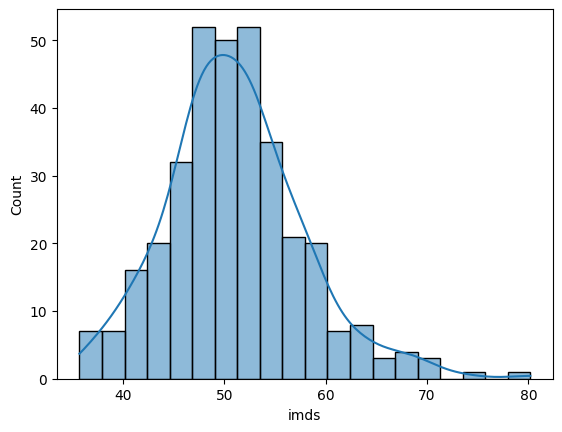

In [6]:
sns.histplot(x=gdf[INDICATOR1], kde=True);

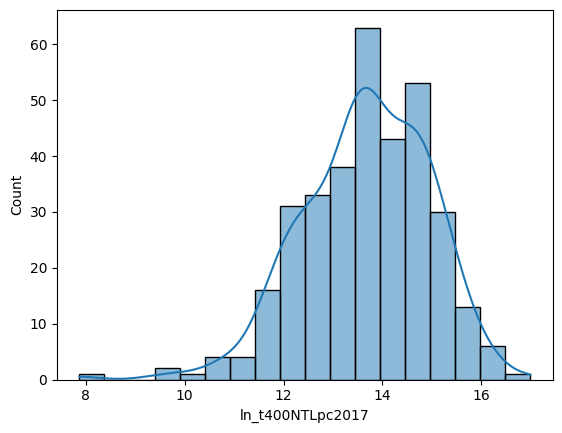

In [7]:
sns.histplot(x=gdf[INDICATOR3], kde=True);

## Theil index

In [8]:
theil_INDICATOR1 = inequality.theil.Theil(gdf[INDICATOR1].values).T
theil_INDICATOR1

np.float64(0.008639875162700268)

In [9]:
theil_INDICATOR3 = inequality.theil.Theil(gdf[INDICATOR3].values).T
theil_INDICATOR3

np.float64(0.004464226831497372)

### Theil decomposition

- How much inequality is *between* departments vs *within* departments?

In [10]:
gdf.explore(
    column=ADM1,
    tooltip=[ADM1, ADM3, INDICATOR1, INDICATOR4],
    categorical=True,
    legend=True,
    tiles='CartoDB positron',
    style_kwds=dict(color="gray", weight=0.6),
    legend_kwds=dict(colorbar=False)
)

In [11]:
theil_BW_INDICATOR1 = inequality.theil.TheilD(gdf[INDICATOR1].values, gdf[ADM1])
theil_B_INDICATOR1 = theil_BW_INDICATOR1.bg
theil_W_INDICATOR1 = theil_BW_INDICATOR1.wg

In [12]:
print("IMDS — Between-department share:", theil_B_INDICATOR1 / theil_INDICATOR1)
print("IMDS — Within-department share: ", theil_W_INDICATOR1 / theil_INDICATOR1)

IMDS — Between-department share: [0.18203423]
IMDS — Within-department share:  [0.81796577]


In [13]:
theil_BW_INDICATOR3 = inequality.theil.TheilD(gdf[INDICATOR3].values, gdf[ADM1])
theil_B_INDICATOR3 = theil_BW_INDICATOR3.bg
theil_W_INDICATOR3 = theil_BW_INDICATOR3.wg

In [14]:
print("NTL — Between-department share:", theil_B_INDICATOR3 / theil_INDICATOR3)
print("NTL — Within-department share: ", theil_W_INDICATOR3 / theil_INDICATOR3)

NTL — Between-department share: [0.19676431]
NTL — Within-department share:  [0.80323569]


## Gini index

In [15]:
print("Gini (IMDS):", inequality.gini.Gini(gdf[INDICATOR1].values).g)
print("Gini (NTL): ", inequality.gini.Gini(gdf[INDICATOR3].values).g)

Gini (IMDS): 0.07282132196446878
Gini (NTL):  0.0521407680211148


### Spatial Gini

- What share of inequality is between neighbouring municipalities?

In [16]:
W = weights.KNN.from_dataframe(gdf, k=6)
W.transform = 'r'

In [17]:
sg1 = Gini_Spatial(gdf[INDICATOR1], W)
print("IMDS — Spatial Gini share:", sg1.wcg_share, ", p-value:", sg1.p_sim)

IMDS — Spatial Gini share: 0.07185407731996797 , p-value: 0.01


In [18]:
sg3 = Gini_Spatial(gdf[INDICATOR3], W)
print("NTL — Spatial Gini share:", sg3.wcg_share, ", p-value:", sg3.p_sim)

NTL — Spatial Gini share: 0.0514693370418708 , p-value: 0.01
